# Detectar  e  prever  tentativas  de transações fraudulentas em compras online

Neste  projeto  vamos  aplicar  Inteligência  Artificial  para  detectar  e  prever  tentativas  de transações fraudulentas em compras online.Trabalharemos  com  dados  reais  que estão  altamente  desbalanceados  (o  que  é  normal com  relação  a  dados  de  transações  fraudulentas). Os  dados  estão  disponíveis  no  link:
- https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

O conjunto  de  dados  contém  transações  feitas  por  cartões  de  crédito  em  setembro  de 2013 por titulares de cartões europeus. Este conjunto de dados apresenta transações ocorridas em dois dias, onde temos 492 fraudes em 284.807 transações. O conjunto de dadosé altamente desbalanceado, a classe positiva (fraudes) responde por 0,17% de todas as transações

In [1]:
!pip install -q threadpoolctl

In [2]:
!pip install --upgrade pip

In [3]:
!pip install imbalanced-learn

In [4]:
!pip show imbalanced-learn

Name: imbalanced-learn
Version: 0.14.0
Summary: Toolbox for imbalanced dataset in machine learning
Home-page: https://imbalanced-learn.org/
Author: 
Author-email: "G. Lemaitre" <g.lemaitre58@gmail.com>, "C. Aridas" <ichkoar@gmail.com>
License: 
Location: /Users/vinicius/.pyenv/versions/3.11.7/lib/python3.11/site-packages
Requires: joblib, numpy, scikit-learn, scipy, threadpoolctl
Required-by: 


In [5]:
from imblearn.over_sampling import SMOTE
print("SMOTE importado com sucesso!")

SMOTE importado com sucesso!


In [6]:
import joblib
import threadpoolctl
import sklearn 
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest 
from sklearn.neighbors import LocalOutlierFactor 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from pylab import rcParams
rcParams["figure.figsize"] = 14,8
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("dataset.csv", sep = ',')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.901288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dados anonimizados

In [8]:
df.shape

(284807, 31)

## Análise Exploratória 

`Transações normais X Transações Fraudulentas`

In [10]:
df.isnull().sum().max()

0

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

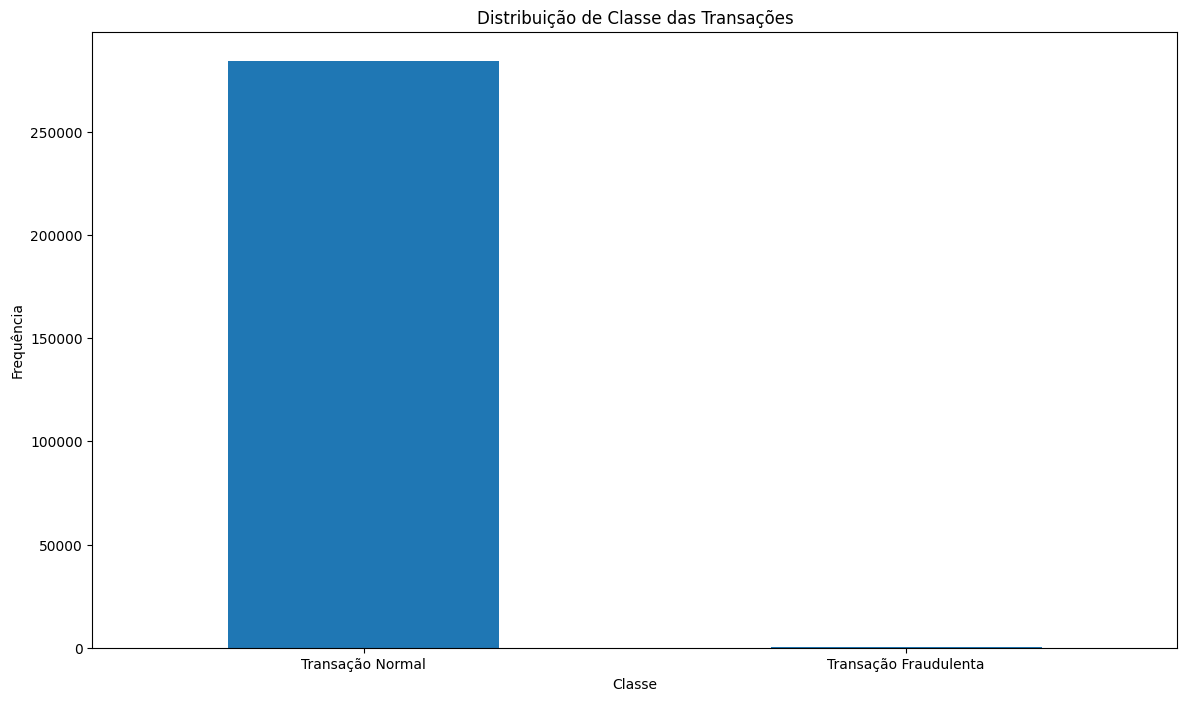

In [13]:
# Plot
# 0 significa: Transação Normal 
# 1 significa: Transação Fraudulenta
LABELS = ["Transação Normal", "Transação Fraudulenta"]
count_classes = pd.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot = 0)
plt.title("Distribuição de Classe das Transações")
plt.xticks(range(2), LABELS)
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.show();

### Calculando a Proporção de Transações Normais x Transações Fraudulentas

In [14]:
# Fraude = 1, normal = 0
fraude = df[df["Class"]==1]
normal = df[df["Class"]==0]

print(fraude.shape, normal.shape)

(492, 31) (284315, 31)


In [15]:
# Em valor percentual
print("Transações Normais:", round(df["Class"]. value_counts()[0]/len(df)*100,2), "% dos dados")
print("Transações Fraudulentas", round(df["Class"]. value_counts()[1]/len(df)*100,2), "% dos dados")

Transações Normais: 99.83 % dos dados
Transações Fraudulentas 0.17 % dos dados


In [16]:
# Resumo estatístico das transações fraudulentas
fraude.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

**Análise**:
A partir desta tabela, podemos verificar que o valor mínimo para transações fraudulentas foi de 0,000 e o valor máximo foi de 2.125,87 dólares. A média de transações fraudulentas foi de $122.21 e as transações fraudulentas ocorreram cerca de 492 vezes.

In [17]:
normal.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

**Análise**:

A partir desta tabela, podemos verificar que o valor mínimo para transações normais foi de 0,000 e o valor máximo foi de 25.691,16 dólares. A média de transações normais foi de $88.291 e as transações normais ocorreram cerca de 284.315 vezes.

### Histograma e Distribuição das Transações

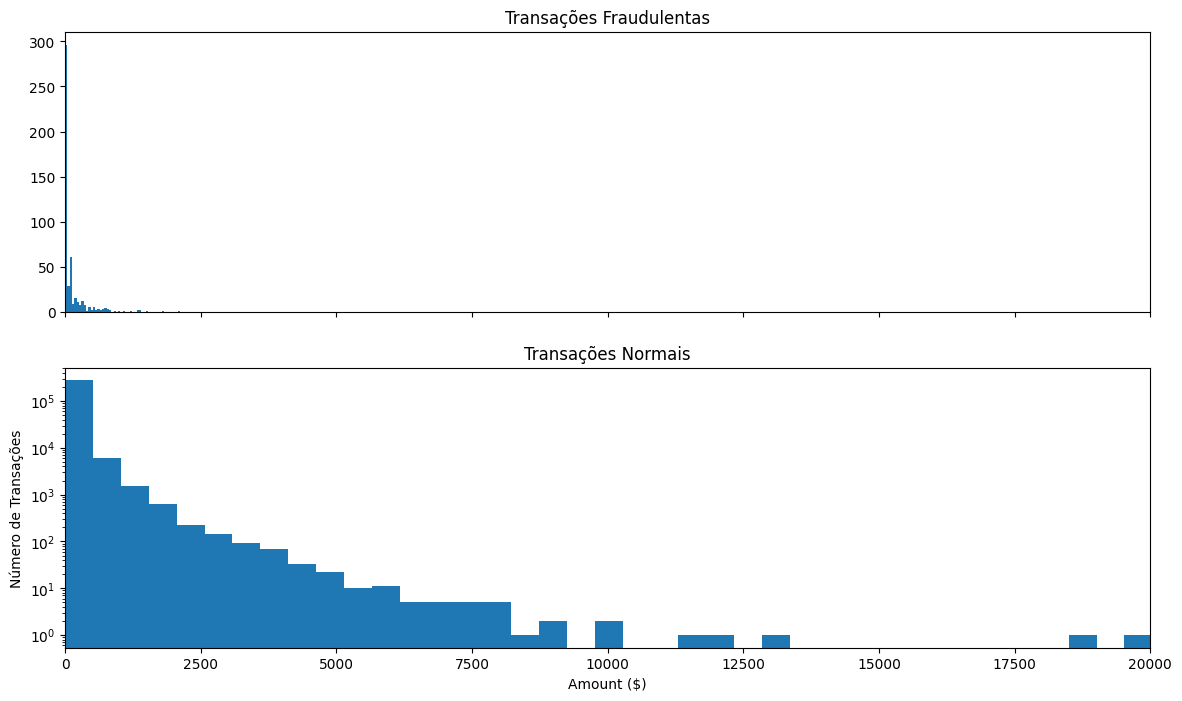

In [18]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
bins = 50
ax1.hist(fraude.Amount, bins = bins)
ax1.set_title('Transações Fraudulentas')
ax2.hist(normal.Amount, bins = bins)
ax2.set_title('Transações Normais')
plt.xlabel('Amount ($)')
plt.ylabel('Número de Transações')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show();

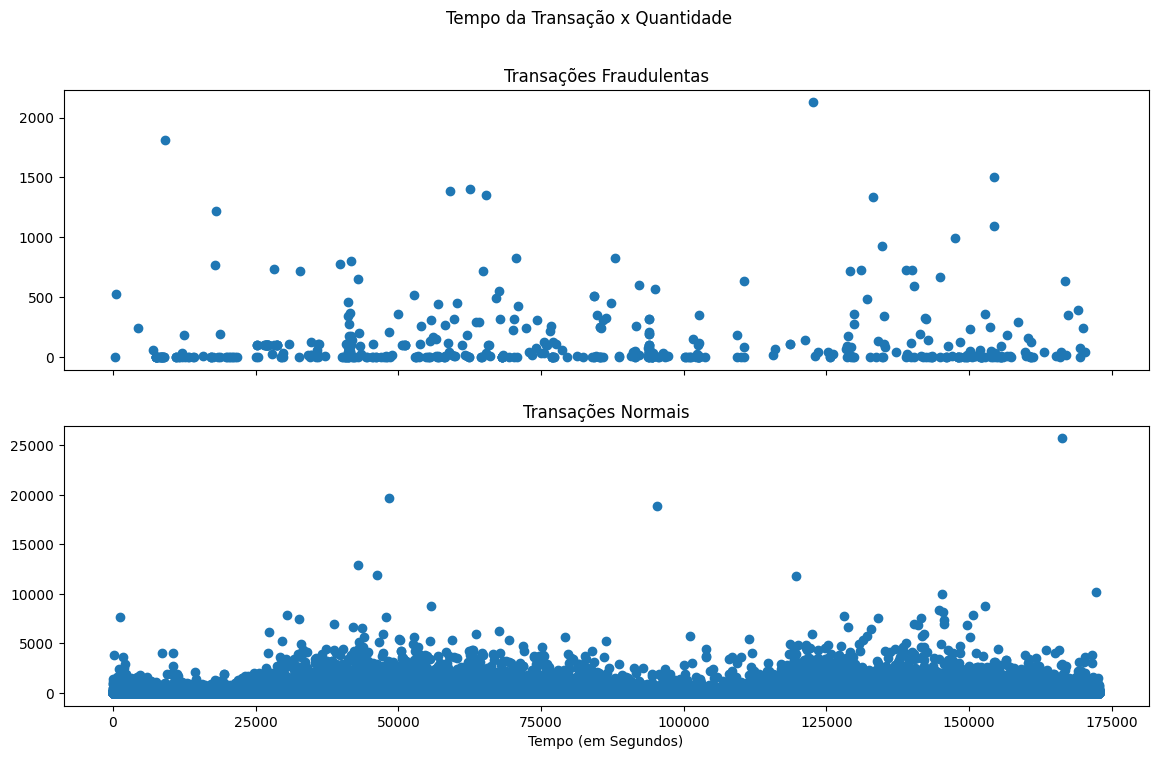

In [19]:
# Distribuição das transações pelo tempo
f, (ax1, ax2) = plt.subplots(2, 1, sharex = True)
f.suptitle('Tempo da Transação x Quantidade')
ax1.scatter(fraude.Time, fraude.Amount)
ax1.set_title('Transações Fraudulentas')
ax2.scatter(normal.Time, normal.Amount)
ax2.set_title('Transações Normais')
plt.xlabel('Tempo (em Segundos)')
plt.show();

`A variável TEMPO não parece relevante, não tem uma influência para sabermos se é uma transação normal ou fraudulenta`

### Correlação Entre os Atributos das Transações Online

Vamos trabalhar com amostras para simplificar, a analise e treinar modelos de forma mais interativa e rapida

In [20]:
amostra = df.sample(frac = 0.1, random_state = 1)
amostra.shape

(28481, 31)

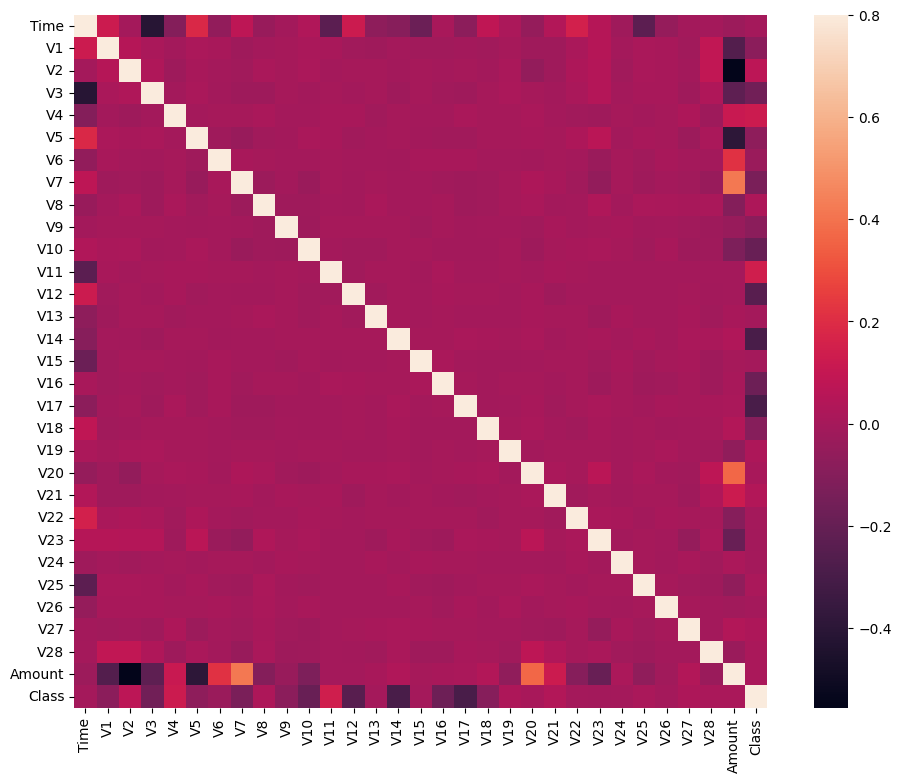

In [21]:
correlation_matrix = amostra.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(correlation_matrix, vmax = 0.8, square = True)
plt.show()

**Análise**:
A matriz de correlação acima mostra que nenhum dos componentes V1 a V28 tem forte correlação entre si. No entanto, observarmos que a classe tem algumas correlações positivas e negativas com os componentes V, mas não tem forte correlação com o tempo e a quantidade.

Os coeficientes de correlação medem a força e a direção da relação linear entre duas variáveis. A interpretação dos coeficientes de correlação é a seguinte:

- **1 ou -1**: Correlação perfeita. Uma variável muda exatamente de acordo com a outra.
- **0,7 a 0,9 (ou -0,7 a -0,9)**: Correlação forte.
- **0,4 a 0,6 (ou -0,4 a -0,6)**: Correlação moderada.
- **0,1 a 0,3 (ou -0,1 a -0,3)**: Correlação fraca.
- **0**: Nenhuma correlação linear.

Direção do Coeficiente:

- Positivo (+): À medida que uma variável aumenta, a outra também tende a aumentar.
- Negativo (-): À medida que uma variável aumenta, a outra tende a diminuir.

Limitações:

- O coeficiente de correlação só mede a relação linear entre as variáveis. Relações não lineares podem ter coeficientes próximos de zero, mesmo que exista uma relação forte.
- A correlação não implica causalidade. Mesmo com uma correlação alta, uma variável não necessariamente causa mudanças na outra.

### Pré Processamento de Dados

In [23]:
# Determinamos o número de fraudes e transações válidas na amostra de dados
Fraude = amostra[amostra['Class']==1]
Valid = amostra[amostra['Class']==0]

# Fraudes sao outliers, vamos calcular a proporcao e usar mais tarde nos modelos
outlier_fraction = len(Fraude) / float(len(Valid)) * 100

# Imprime a fração e o número de casos de Fraude e Transação Válida
print("\nCasos Fraudulentos : {}".format(len(Fraude)))
print("\nCasos Válidos : {}".format(len(Valid)))
print("\nPercentual de Transações Anormais (Fraudulentas): ", outlier_fraction)


Casos Fraudulentos : 49

Casos Válidos : 28432

Percentual de Transações Anormais (Fraudulentas):  0.17234102419808667


In [24]:
#variaveis preditoras 
columns = amostra.columns.tolist()

In [25]:
# Filtra a coluna com a variavel target e remove a variavel time
columns = [c for c in columns if c not in ["Class", "Time"]]

In [26]:
target = "Class"

state = np.random.RandomState(42)

X = amostra[columns]
Y = amostra[target]

print(X.shape, Y.shape)

(28481, 29) (28481,)


### Modelagem Antes do Balanceamento de Classe com Aprendizado Não Supervisionado
**Primeiro vou utilziar os dados desbalanceados para treinar e ver a diferença entre utilizar com dados desbalanceados e balanceados, ou seja, vamos verificar se a nível de algoritmo conseguimos resolver o problema, caso contrário, precisaremos mexer nos dados**


Os algoritmos que decidimos usar para tentar fazer a detecção de anomalias neste conjunto de dados são o algoritmo Isolation Forest e Local Outlier Factor (LOF).

`Isolation Forest Algorithm:` O Isolation Forest Algorithm é um algoritmo de aprendizado de máquina não supervisionado que é usado principalmente para **detecção de anomalias**. Ele se baseia na ideia de que as anomalias são poucas e diferentes dos dados normais, portanto, são mais fáceis de isolar.

`Local Outilier Factor (LOF) Algorithm:` O Local Outlier Factor (LOF) é um algoritmo de aprendizado de máquina não supervisionado usado para identificar pontos de dados anômalos, também conhecidos como outliers, em um conjunto de dados. O LOF baseia-se na ideia de que os pontos de dados normais tendem a estar próximos uns dos outros em um espaço de atributos, enquanto os outliers estão mais distantes dos pontos de dados normais. O algoritmo estima a densidade local de cada ponto e compara com a densidade dos seus vizinhos para identificar outliers

In [29]:
# Modelos de Detecção de Outliers
classificadores = {
    
    "Isolation Forest":IsolationForest(n_estimators = 100, 
                                       max_samples = len(X), 
                                       contamination = outlier_fraction, #calculamos mais cedo
                                       random_state = state, 
                                       verbose = 0),
    
    "Local Outlier Factor":LocalOutlierFactor(n_neighbors = 10, 
                                              algorithm = 'auto', 
                                              leaf_size = 30, 
                                              metric = 'minkowski',
                                              p = 2, 
                                              metric_params = None, 
                                              contamination = outlier_fraction)
   
}

### Treinamento e avaliação

# Loop de treino
for i, (clf_name, clf) in enumerate(classificadores.items()):
    
    # Fit 
    if clf_name == "Local Outlier Factor":
        
        # Faz previsão com o modelo
        y_pred = clf.fit_predict(X)
        
        # Calcula o score
        scores_prediction = clf.negative_outlier_factor_
        
        # Salva o modelo
        modelo_lof = clf
    
    else:    
        
        # Fit
        clf.fit(X)
        
        # Score
        scores_prediction = clf.decision_function(X)
        
        # Previsão
        y_pred = clf.predict(X)
        
        # Salva o modelo
        modelo_if = clf
    
    # Reshape dos valores das previsões para 0 (transações válidas) e 1 (transações fraudulentas)
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1
    n_errors = (y_pred != Y).sum()
    
    # Métricas
    print("{}".format(clf_name))
    print("\nAccuracy Score:", accuracy_score(Y,y_pred))
    print("\nClassification Report:")
    print(classification_report(Y,y_pred))

**Análise**:

Os 2 modelos apresentaram alta acurácia (métrica global), mas valores bem diferentes de precision e recall (métricas locais). A performance do Isolation Forest foi superior.

Precision mede a proporção de previsões positivas que estão corretas. Ou seja, entre todas as instâncias que o modelo previu como positivas, quantas realmente eram positivas. Precision foca na qualidade das previsões positivas (o que mais nos interessa neste projeto).

Recall mede a capacidade do modelo de encontrar todas as instâncias positivas. Ou seja, entre todas as instâncias que realmente são positivas, quantas o modelo identificou corretamente. Recall foca na quantidade de previsões positivas corretas que o modelo conseguiu identificar.

### Modelagem Depois do Balanceamento de Classe com Aprendizado Supervisionado

Vamos aplicar o balanceamento de classe utilizando o **SMOTE** e criar um modelo com algoritmo RandomForest

Essa técnica (SMOTE) também conhecida como over-sampling, cria dados sintéticos da classe minoritária (transacao fraudulenta) até que a base de treinamento atinja o equilíbrio 50% para as classes.

In [32]:
data = pd.read_csv("dataset.csv")

#separar caracteristicas (x) e variavel alvo 
X = data.drop(columns=['Class', 'Time'])
y = data['Class']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [35]:
# Balancear as classes no conjunto de treino usando SMOTE
smote = SMOTE(random_state = 42)
X_treino_balanced, y_treino_balanced = smote.fit_resample(X_treino, y_treino)

print(f"Contagem da classe de treino sem o SMOTE: {y_treino.value_counts()}")

Contagem da classe de treino sem o SMOTE: Class
0    199008
1       356
Name: count, dtype: int64


In [36]:
print(f"Contagem da classe de treino com o SMOTE: {y_treino_balanced.value_counts()}")

Contagem da classe de treino com o SMOTE: Class
0    199008
1    199008
Name: count, dtype: int64


In [37]:
# Padronizar os dados (importante para modelos que utilizam distância como métrica)
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino_balanced)
X_teste_scaled = scaler.transform(X_teste)

In [45]:
%%time
modelo = RandomForestClassifier(n_estimators = 50, random_state = 42) #randomforest por padrao coloca 100 de n_estimators (arvores)
modelo.fit(X_treino_scaled, y_treino_balanced)

CPU times: user 1min 27s, sys: 253 ms, total: 1min 28s
Wall time: 1min 28s


RandomForestClassifier(n_estimators=50, random_state=42)

In [46]:
# Previsões no conjunto de teste
y_pred = modelo.predict(X_teste_scaled)

In [47]:
# Salva o modelo em disco
joblib.dump(modelo, 'modelo_treinado_50_est.pkl')

['modelo_treinado_50_est.pkl']

In [48]:
# Salva o scaler no disco
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [49]:
# Avalia o modelo
print("\nAcurácia:", accuracy_score(y_teste, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred))


Acurácia: 0.9995318516437859

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.85      0.86      0.85       136

    accuracy                           1.00     85443
   macro avg       0.92      0.93      0.93     85443
weighted avg       1.00      1.00      1.00     85443



### Deploy e previsões do modelo

A transação abaixo é fraudulenta

In [50]:
# Dados de uma nova transação
nova_transacao_1 = [-2.3122265423263,1.95199201064158,-1.60985073229769,3.9979055875468,-0.522187864667764,-1.42654531920595,-2.53738730624579,1.39165724829804,-2.77008927719433,-2.77227214465915,3.20203320709635,-2.89990738849473,-0.595221881324605,-4.28925378244217,0.389724120274487,-1.14074717980657,-2.83005567450437,-0.0168224681808257,0.416955705037907,0.126910559061474,0.517232370861764,-0.0350493686052974,-0.465211076182388,0.320198198514526,0.0445191674731724,0.177839798284401,0.261145002567677,-0.143275874698919,0]

In [51]:
# Ajusta o shape
nova_transacao_arr_1 = np.array(nova_transacao_1).reshape(1, -1)

In [52]:
# Carrega o scaler salvo do disco
scaler_carregado = joblib.load('scaler.pkl')

In [53]:
# Padroniza os novos dados com o mesmo scaler usado no treino
novos_dados_scaled = scaler_carregado.transform(nova_transacao_arr_1)

In [54]:
# Carrega o modelo do disco
modelo_carregado = joblib.load('modelo_treinado_50_est.pkl')

In [55]:
# Fazer previsões com o modelo treinado
previsao = modelo_carregado.predict(novos_dados_scaled)

In [56]:
# Resultado
if previsao == 0:
    print("Essa transação não é tentativa de fraude!")
else:
    print("Essa transação é, provavelmente, tentativa de fraude!")

Essa transação é, provavelmente, tentativa de fraude!
